In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from statsmodels.stats.proportion import proportions_ztest
from pathlib import Path

# 1. 讀取乾淨的資料
ROOT = Path.cwd().resolve().parent
PROCESSED_PATH = ROOT / "data" / "processed" / "yrbs_smoking_cleaned.csv"
if not PROCESSED_PATH.exists():
    PROCESSED_PATH = Path("../data/processed/yrbs_smoking_cleaned.csv")
FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"
df = pd.read_csv(PROCESSED_PATH)
sns.set_theme(style="whitegrid")

print(f"成功讀取資料，總計有效樣本: {len(df)} 筆\n")

成功讀取資料，總計有效樣本: 11301 筆



延伸分析一：Two-Sample t-Test for Alcohol Proportions
抽菸組總人數: 2221, 飲酒人數: 1941 (比例: 87.39%)
不抽菸組總人數: 9080, 飲酒人數: 3114 (比例: 34.30%)
t 統計量: 61.5390
t 檢定 p-value: 0.0000e+00


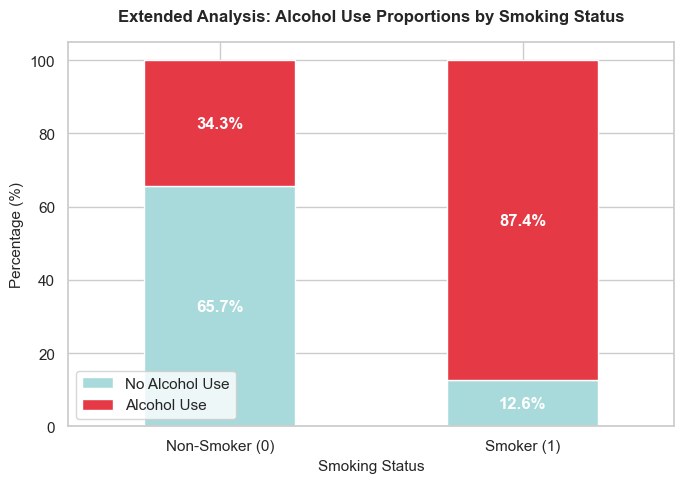

In [3]:
print("延伸分析一：Two-Sample t-Test for Alcohol Proportions")

import scipy.stats as stats

# 排除缺失值以確保檢定準確
clean_df_alc = df.dropna(subset=['Smoking_Status', 'Alcohol_Status'])

# 分離出抽菸組與不抽菸組的酒精虛擬變數資料 (0 或 1)
smoker_alc = clean_df_alc[clean_df_alc['Smoking_Status'] == 1]['Alcohol_Status']
non_smoker_alc = clean_df_alc[clean_df_alc['Smoking_Status'] == 0]['Alcohol_Status']

n_smoker = len(smoker_alc)
n_non_smoker = len(non_smoker_alc)

success_alcohol_smoker = smoker_alc.sum()
success_alcohol_non_smoker = non_smoker_alc.sum()

# 執行 Two-sample t-test (不假設兩組變異數相等，使用 Welch's t-test)
t_stat_alc, p_val_alc = stats.ttest_ind(smoker_alc, non_smoker_alc, equal_var=False)

print(f"抽菸組總人數: {n_smoker}, 飲酒人數: {success_alcohol_smoker} (比例: {success_alcohol_smoker/n_smoker:.2%})")
print(f"不抽菸組總人數: {n_non_smoker}, 飲酒人數: {success_alcohol_non_smoker} (比例: {success_alcohol_non_smoker/n_non_smoker:.2%})")
print(f"t 統計量: {t_stat_alc:.4f}")
print(f"t 檢定 p-value: {p_val_alc:.4e}")

# 繪製百分比堆疊長條圖
table_alc_pct = pd.crosstab(clean_df_alc['Smoking_Status'], clean_df_alc['Alcohol_Status'], normalize='index') * 100
fig, ax1 = plt.subplots(figsize=(7, 5))
table_alc_pct.plot(kind='bar', stacked=True, color=['#A8DADC', '#E63946'], ax=ax1)
plt.title("Extended Analysis: Alcohol Use Proportions by Smoking Status", fontsize=12, weight='bold', pad=15)
plt.xlabel("Smoking Status", fontsize=11)
plt.ylabel("Percentage (%)", fontsize=11)
plt.xticks(ticks=[0, 1], labels=["Non-Smoker (0)", "Smoker (1)"], rotation=0)
plt.legend(["No Alcohol Use", "Alcohol Use"], loc='lower left')
for p in ax1.patches:
    h = p.get_height()
    if h > 0: ax1.annotate(f'{h:.1f}%', (p.get_x() + p.get_width()/2, p.get_y() + h/2), ha='center', va='center', color='white', weight='bold')
plt.tight_layout()
plt.show()

延伸分析二：Two-Sample t-Test for Marijuana Proportions
抽菸組總人數: 2221, 大麻人數: 1309 (比例: 58.94%)
不抽菸組總人數: 9080, 大麻人數: 932 (比例: 10.26%)
t 統計量: 44.5887
t 檢定 p-value: 0.0000e+00


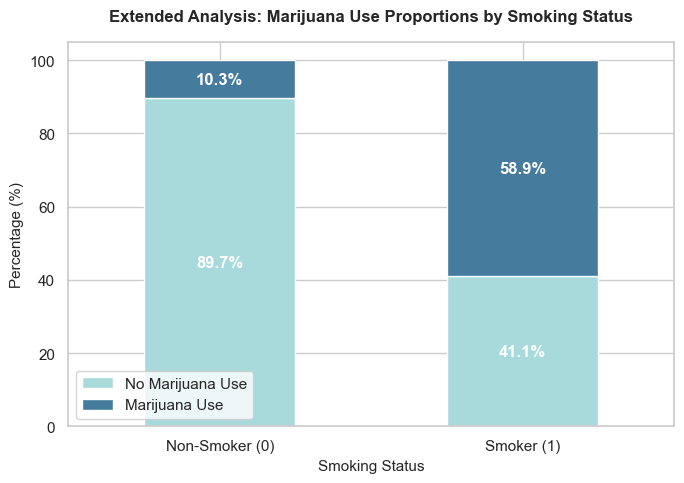

In [4]:
print("延伸分析二：Two-Sample t-Test for Marijuana Proportions")

import scipy.stats as stats

# 排除缺失值以確保檢定準確
clean_df_mar = df.dropna(subset=['Smoking_Status', 'Marijuana_Status'])

# 分離出抽菸組與不抽菸組的大麻虛擬變數資料 (0 或 1)
smoker_mar = clean_df_mar[clean_df_mar['Smoking_Status'] == 1]['Marijuana_Status']
non_smoker_mar = clean_df_mar[clean_df_mar['Smoking_Status'] == 0]['Marijuana_Status']

n_smoker = len(smoker_mar)
n_non_smoker = len(non_smoker_mar)

success_marijuana_smoker = smoker_mar.sum()
success_marijuana_non_smoker = non_smoker_mar.sum()

# 執行 Two-sample t-test (不假設兩組變異數相等，使用 Welch's t-test)
t_stat_mar, p_val_mar = stats.ttest_ind(smoker_mar, non_smoker_mar, equal_var=False)

print(f"抽菸組總人數: {n_smoker}, 大麻人數: {success_marijuana_smoker} (比例: {success_marijuana_smoker/n_smoker:.2%})")
print(f"不抽菸組總人數: {n_non_smoker}, 大麻人數: {success_marijuana_non_smoker} (比例: {success_marijuana_non_smoker/n_non_smoker:.2%})")
print(f"t 統計量: {t_stat_mar:.4f}")
print(f"t 檢定 p-value: {p_val_mar:.4e}")

# 繪製百分比堆疊長條圖
table_mar_pct = pd.crosstab(clean_df_mar['Smoking_Status'], clean_df_mar['Marijuana_Status'], normalize='index') * 100
fig, ax2 = plt.subplots(figsize=(7, 5))
table_mar_pct.plot(kind='bar', stacked=True, color=['#A8DADC', '#457B9D'], ax=ax2)
plt.title("Extended Analysis: Marijuana Use Proportions by Smoking Status", fontsize=12, weight='bold', pad=15)
plt.xlabel("Smoking Status", fontsize=11)
plt.ylabel("Percentage (%)", fontsize=11)
plt.xticks(ticks=[0, 1], labels=["Non-Smoker (0)", "Smoker (1)"], rotation=0)
plt.legend(["No Marijuana Use", "Marijuana Use"], loc='lower left')
for p in ax2.patches:
    h = p.get_height()
    if h > 0: ax2.annotate(f'{h:.1f}%', (p.get_x() + p.get_width()/2, p.get_y() + h/2), ha='center', va='center', color='white', weight='bold')
plt.tight_layout()
plt.show()

多重成癮物質之相關性矩陣熱圖 (Heatmap)


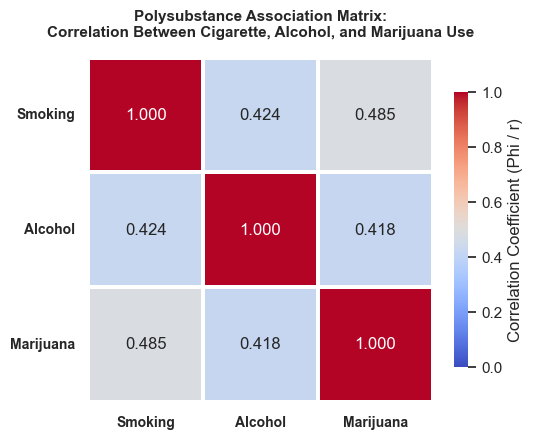

In [5]:
print("多重成癮物質之相關性矩陣熱圖 (Heatmap)")

matrix_cols = ['Smoking_Status', 'Alcohol_Status', 'Marijuana_Status']
corr_matrix = df[matrix_cols].corr()

plt.figure(figsize=(5.5, 4.5))

# 改用 sns.heatmap，徹底關掉 clustermap 的樹狀圖連結線
sns.heatmap(
    corr_matrix,            # 讀取計算好的矩陣
    annot=True,             # 在格子內顯示相關係數數字
    fmt=".3f",              # 數字顯示到小數點後三位
    cmap="coolwarm",        # 專業文獻常用的標準藍紅對比色調
    vmin=0, vmax=1,         # 設定相關係數範圍
    square=True,            # 讓格子保持正方形
    linewidths=1.5,         # 格子之間的白色分隔線，讓視覺更俐落
    cbar_kws={'label': "Correlation Coefficient (Phi / r)", 'shrink': 0.8}
)

# 美化圖表細節
plt.title("Polysubstance Association Matrix:\nCorrelation Between Cigarette, Alcohol, and Marijuana Use", 
          fontsize=11, weight='bold', pad=15)

# 調整座標軸文字，確保乾淨不擠壓
plt.xticks(ticks=[0.5, 1.5, 2.5], labels=['Smoking', 'Alcohol', 'Marijuana'], fontsize=10, weight='bold')
plt.yticks(ticks=[0.5, 1.5, 2.5], labels=['Smoking', 'Alcohol', 'Marijuana'], fontsize=10, weight='bold', rotation=0)
plt.savefig(FIG_DIR / "04_heatmap_plot.png", dpi=120)
plt.tight_layout()
plt.show()

專業視覺化：抽菸狀態下其他物質使用之條件機率對比


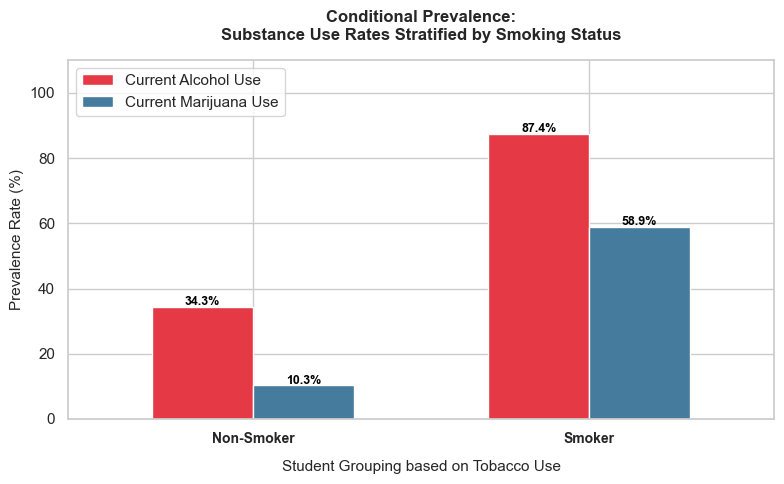

In [6]:
print("專業視覺化：抽菸狀態下其他物質使用之條件機率對比")

# 1. 根據之前的分組計算實際的使用比例
p_alc_nonsmoker = (df[df['Smoking_Status'] == 0]['Alcohol_Status'] == 1).mean() * 100
p_alc_smoker = (df[df['Smoking_Status'] == 1]['Alcohol_Status'] == 1).mean() * 100

p_mar_nonsmoker = (df[df['Smoking_Status'] == 0]['Marijuana_Status'] == 1).mean() * 100
p_mar_smoker = (df[df['Smoking_Status'] == 1]['Marijuana_Status'] == 1).mean() * 100

# 2. 建立繪圖矩陣
prob_df = pd.DataFrame({
    'Current Alcohol Use': [p_alc_nonsmoker, p_alc_smoker],
    'Current Marijuana Use': [p_mar_nonsmoker, p_mar_smoker]
}, index=['Non-Smoker', 'Smoker'])

# 3. 繪製並排長條圖
ax = prob_df.plot(kind='bar', figsize=(8, 5), color=['#E63946', '#457B9D'], width=0.6)

# 4. 在每個長條圖頂端自動加上百分比標籤
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{h:.1f}%', (p.get_x() + p.get_width()/2, h + 1.5), 
                    ha='center', va='center', color='black', weight='bold', fontsize=9)

# 5. 美化細節
plt.title("Conditional Prevalence:\nSubstance Use Rates Stratified by Smoking Status", fontsize=12, weight='bold', pad=15)
plt.ylabel("Prevalence Rate (%)", fontsize=11)
plt.xlabel("Student Grouping based on Tobacco Use", fontsize=11, labelpad=10)
plt.xticks(rotation=0, fontsize=10, weight='bold')
plt.ylim(0, 110)
plt.legend(frameon=True, loc='upper left')
plt.savefig(FIG_DIR / "05_conditional_probability_plot.png", dpi=120)
plt.tight_layout()
plt.show()

區分男女性別的條件盛行率並排對比圖


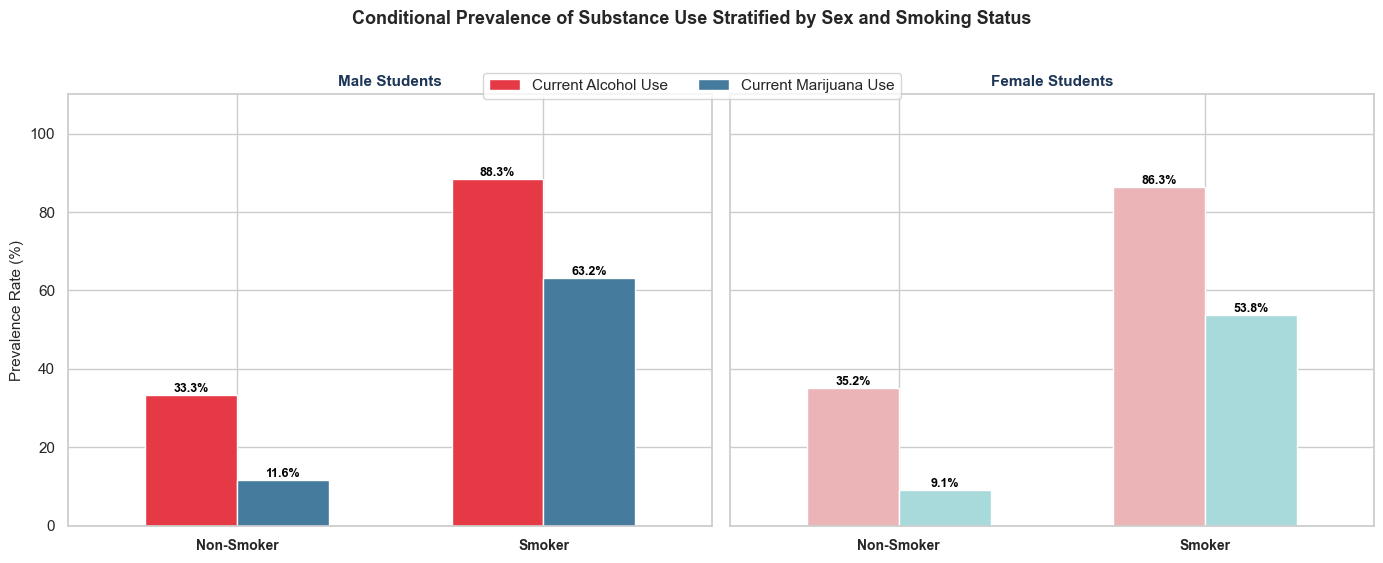

In [7]:
print("區分男女性別的條件盛行率並排對比圖")

# 1. 【男生組 (Male, Sex==2)】條件比例計算
df_male = df[df['WhatIsYourSex'] == 2]
m_alc_nonsmoker = (df_male[df_male['Smoking_Status'] == 0]['Alcohol_Status'] == 1).mean() * 100
m_alc_smoker    = (df_male[df_male['Smoking_Status'] == 1]['Alcohol_Status'] == 1).mean() * 100
m_mar_nonsmoker = (df_male[df_male['Smoking_Status'] == 0]['Marijuana_Status'] == 1).mean() * 100
m_mar_smoker    = (df_male[df_male['Smoking_Status'] == 1]['Marijuana_Status'] == 1).mean() * 100

male_prob_df = pd.DataFrame({
    'Current Alcohol Use': [m_alc_nonsmoker, m_alc_smoker],
    'Current Marijuana Use': [m_mar_nonsmoker, m_mar_smoker]
}, index=['Non-Smoker', 'Smoker'])

# 2. 【女生組 (Female, Sex==1)】條件比例計算
df_female = df[df['WhatIsYourSex'] == 1]
f_alc_nonsmoker = (df_female[df_female['Smoking_Status'] == 0]['Alcohol_Status'] == 1).mean() * 100
f_alc_smoker    = (df_female[df_female['Smoking_Status'] == 1]['Alcohol_Status'] == 1).mean() * 100
f_mar_nonsmoker = (df_female[df_female['Smoking_Status'] == 0]['Marijuana_Status'] == 1).mean() * 100
f_mar_smoker    = (df_female[df_female['Smoking_Status'] == 1]['Marijuana_Status'] == 1).mean() * 100

female_prob_df = pd.DataFrame({
    'Current Alcohol Use': [f_alc_nonsmoker, f_alc_smoker],
    'Current Marijuana Use': [f_mar_nonsmoker, f_mar_smoker]
}, index=['Non-Smoker', 'Smoker'])


# 3. 開始繪製左右並排的雙子圖 (1列 2行)
fig, (ax_m, ax_f) = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True) # sharey=True 確保左右Y軸刻度一致，方便對比

# ➔ 繪製左圖：男生組
male_prob_df.plot(kind='bar', ax=ax_m, color=['#E63946', '#457B9D'], width=0.6)
ax_m.set_title("Male Students", fontsize=11, weight='bold', color='#1D3557')
ax_m.set_ylabel("Prevalence Rate (%)", fontsize=11)
ax_m.set_xticklabels(['Non-Smoker', 'Smoker'], rotation=0, fontsize=10, weight='bold')
ax_m.set_ylim(0, 110)
ax_m.get_legend().remove() # 先移除左圖圖例，最後統一放中間

# 在男生長條圖頂端加百分比
for p in ax_m.patches:
    h = p.get_height()
    if h > 0: ax_m.annotate(f'{h:.1f}%', (p.get_x() + p.get_width()/2, h + 1.5), ha='center', va='center', color='black', weight='bold', fontsize=9)

# ➔ 繪製右圖：女生組
female_prob_df.plot(kind='bar', ax=ax_f, color=['#EBB5B8', '#A8DADC'], width=0.6) # 女生用稍微柔和的對照色調
ax_f.set_title("Female Students", fontsize=11, weight='bold', color='#1D3557')
ax_f.set_xticklabels(['Non-Smoker', 'Smoker'], rotation=0, fontsize=10, weight='bold')
ax_f.get_legend().remove() # 移除右圖圖例

# 在女生長條圖頂端加百分比
for p in ax_f.patches:
    h = p.get_height()
    if h > 0: ax_f.annotate(f'{h:.1f}%', (p.get_x() + p.get_width()/2, h + 1.5), ha='center', va='center', color='black', weight='bold', fontsize=9)

# 4. 全局美化、整合圖例與大標題
fig.suptitle("Conditional Prevalence of Substance Use Stratified by Sex and Smoking Status", 
             fontsize=13, weight='bold', y=1.02)

# 在全圖上方中央建立統一的圖例
handles_m, labels_m = ax_m.get_legend_handles_labels()
fig.legend(handles_m, ['Current Alcohol Use', 'Current Marijuana Use'], 
           loc='upper center', bbox_to_anchor=(0.5, 0.92), ncol=2, frameon=True)
plt.savefig(FIG_DIR / "06_conditional_probability_by_sex_plot.png", dpi=120)
plt.tight_layout()
plt.show()

In [8]:
print("規範核准檢定：Two-Sample t-Test (吸菸群體內之男女比例對比)")

import scipy.stats as stats

# 1. 篩選出「有吸菸 (Smoking_Status == 1)」且無缺失值的子母體
smoker_only = df[df['Smoking_Status'] == 1].dropna(subset=['WhatIsYourSex'])

# 2. 分離出吸菸群體中，男生(Sex==2)與女生(Sex==1)的酒精與大麻虛擬變數資料 (0 或 1)
male_smoker_df = smoker_only[smoker_only['WhatIsYourSex'] == 2]
female_smoker_df = smoker_only[smoker_only['WhatIsYourSex'] == 1]

# 排除各自行為變數的缺失值以進行精確檢定
male_alc = male_smoker_df['Alcohol_Status'].dropna()
female_alc = female_smoker_df['Alcohol_Status'].dropna()

male_mar = male_smoker_df['Marijuana_Status'].dropna()
female_mar = female_smoker_df['Marijuana_Status'].dropna()

n_male_alc = len(male_alc)
n_female_alc = len(female_alc)
n_male_mar = len(male_mar)
n_female_mar = len(female_mar)

male_alcohol_count = male_alc.sum()
female_alcohol_count = female_alc.sum()
male_marijuana_count = male_mar.sum()
female_marijuana_count = female_mar.sum()


print("[檢定一：飲酒比例男女差異]")
# 執行 Two-sample t-test (不假設兩組變異數相等，使用 Welch's t-test)
t_stat_alc_sex, p_val_alc_sex = stats.ttest_ind(male_alc, female_alc, equal_var=False)

print(f"吸菸男生飲酒率: {male_alcohol_count/n_male_alc:.1%} | 吸菸女生飲酒率: {female_alcohol_count/n_female_alc:.1%}")
print(f"t 統計量: {t_stat_alc_sex:.4f}")
print(f"p-value: {p_val_alc_sex:.4f}")
if p_val_alc_sex < 0.05:
    print("結論：p < 0.05，男女飲酒比例存在【顯著差異】！")
else:
    print("結論：p >= 0.05，男女飲酒比例【沒有顯著差異】，看起來的微小差距只是隨機抽樣誤差。")


print("[檢定二：大麻比例男女差異]")
# 執行 Two-sample t-test (不假設兩組變異數相等，使用 Welch's t-test)
t_stat_mar_sex, p_val_mar_sex = stats.ttest_ind(male_mar, female_mar, equal_var=False)

print(f"吸菸男生大麻率: {male_marijuana_count/n_male_mar:.1%} | 吸菸女生大麻率: {female_marijuana_count/n_female_mar:.1%}")
print(f"t 統計量: {t_stat_mar_sex:.4f}")
print(f"p-value: {p_val_mar_sex:.4e}") # 若數值極小會以科學記號呈現
if p_val_mar_sex < 0.05:
    print("結論：p < 0.05，男女大麻比例存在【極顯著差異】！男生抽菸後涉入大麻的比例顯著高於女生。")
else:
    print("結論：p >= 0.05，男女大麻比例【沒有顯著差異】。")

規範核准檢定：Two-Sample t-Test (吸菸群體內之男女比例對比)
[檢定一：飲酒比例男女差異]
吸菸男生飲酒率: 88.3% | 吸菸女生飲酒率: 86.3%
t 統計量: 1.4405
p-value: 0.1499
結論：p >= 0.05，男女飲酒比例【沒有顯著差異】，看起來的微小差距只是隨機抽樣誤差。
[檢定二：大麻比例男女差異]
吸菸男生大麻率: 63.2% | 吸菸女生大麻率: 53.8%
t 統計量: 4.5117
p-value: 6.7816e-06
結論：p < 0.05，男女大麻比例存在【極顯著差異】！男生抽菸後涉入大麻的比例顯著高於女生。



🔥 正在產生多重物質濫用（Polysubstance Use）之 UpSet Plot...


c:\Users\user\anaconda3\envs\project\lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
c:\Users\user\anaconda3\envs\project\lib\site-packages\upsetplot\plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always be

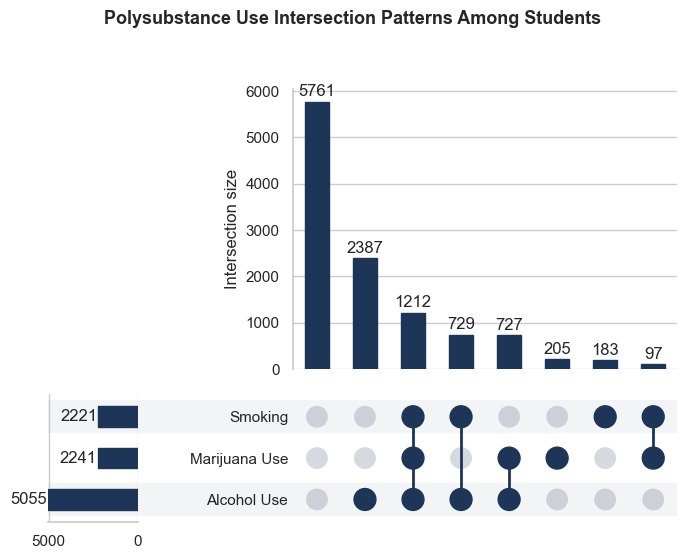

🎉 繪製成功！UpSet Plot 已自動導出至：
➔ C:\Users\user\Desktop\project-cycle--3\outputs\figures\07_polysubstance_upset_plot.png


In [9]:
import sys
import subprocess

# 1. 自動化防錯：檢查並安裝 upsetplot 套件
try:
    import upsetplot
    from upsetplot import from_indicators, plot
except ModuleNotFoundError:
    print("📢 偵測到未安裝 upsetplot 套件，正在自動為您的環境安裝...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "upsetplot"])
    from upsetplot import from_indicators, plot

import pandas as pd
import matplotlib.pyplot as plt

print("\n" + "=" * 60)
print("🔥 正在產生多重物質濫用（Polysubstance Use）之 UpSet Plot...")
print("=" * 60)

# 2. 準備交集矩陣資料
# 將 0 和 1 轉換為 True / False 布林值，這是 UpSetPlot 要求的標準輸入格式
mapping = {1: True, 0: False}
df_bool = pd.DataFrame({
    'Smoking': df['Smoking_Status'].map(mapping),
    'Alcohol Use': df['Alcohol_Status'].map(mapping),
    'Marijuana Use': df['Marijuana_Status'].map(mapping)
})

# 3. 使用 upsetplot 的 from_indicators 自動計算所有交集組合的頻率
upset_data = from_indicators(
    indicators=['Smoking', 'Alcohol Use', 'Marijuana Use'], 
    data=df_bool
)

# 4. 開始繪圖與美化
fig = plt.figure(figsize=(10, 6))

# plot() 會回傳一個字典，裡面包含圖表各個部分的 axes 區塊
upset_plots = plot(
    upset_data, 
    fig=fig, 
    sort_by='cardinality',  # 依組合人數從多到少排序
    show_counts='%d',       # 在長條圖頂端精準顯示該組合的「實際學生人數」
    facecolor='#1D3557',    # 點點與主長條圖顏色（選用深質感藍）
    element_size=45         # 微調點點與格子的間距大小
)

# 5. 精細調整字體與標題
# 透過 upset_plots['totals'] 或是調整全局字體來美化
plt.suptitle("Polysubstance Use Intersection Patterns Among Students", 
             fontsize=13, weight='bold', y=1.02)

# 6. 自動存檔至 outputs/figures/
FIG_DIR = Path("../outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_IMG_PATH = FIG_DIR / "07_polysubstance_upset_plot.png"
plt.savefig(OUTPUT_IMG_PATH, dpi=300, bbox_inches='tight')

plt.show()

print(f"🎉 繪製成功！UpSet Plot 已自動導出至：\n➔ {OUTPUT_IMG_PATH.resolve()}")

正在安全檢查並讀取乾淨資料...
成功由硬碟讀取資料！總計有效樣本: 11301 筆


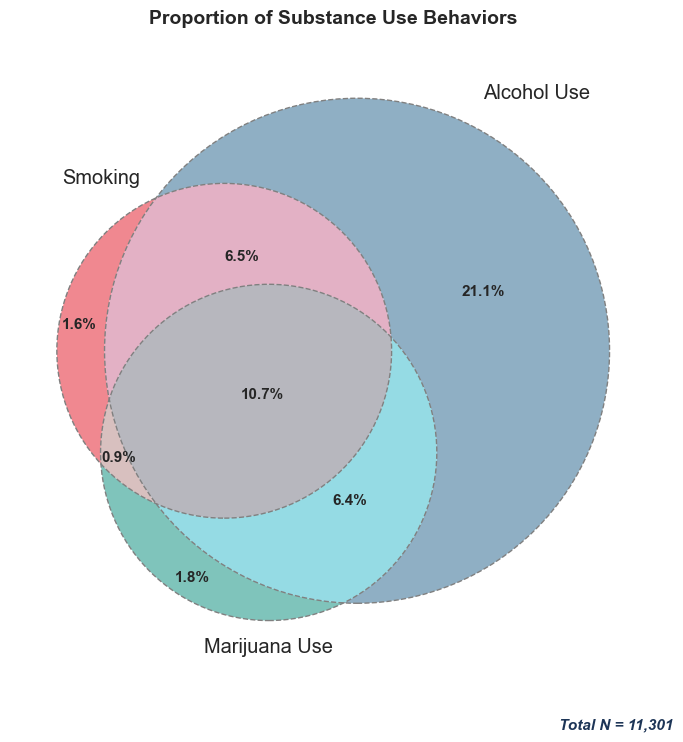

百分比版文氏圖已自動導出至：
➔ C:\Users\user\Desktop\project-cycle--3\outputs\figures\08_polysubstance_venn_percentage_diagram.png


In [10]:

# 三維行為文氏圖 (3-Way Venn Diagram with Percentages)
import sys
import subprocess
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 自動化防錯：檢查並安裝 matplotlib-venn 套件
try:
    import matplotlib_venn
    from matplotlib_venn import venn3, venn3_circles
except ModuleNotFoundError:
    print("📢 偵測到未安裝 matplotlib-venn 套件，正在自動為您的環境安裝...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib-venn"])
    from matplotlib_venn import venn3, venn3_circles

print("正在安全檢查並讀取乾淨資料...")


# 2. 安全防錯機制：如果 df_final 不存在，就主動從硬碟讀取 csv
if 'df_final' not in locals() and 'df_final' not in globals():
    PROCESSED_PATH = Path("../data/processed/yrbs_smoking_cleaned.csv")
    if PROCESSED_PATH.exists():
        df_final = pd.read_csv(PROCESSED_PATH)
        print(f"成功由硬碟讀取資料！總計有效樣本: {len(df_final)} 筆")
    else:
        raise FileNotFoundError(f"❌ 找不到乾淨的 CSV 檔案，請確保 01_data.ipynb 有成功存檔！\n目前預期路徑為: {PROCESSED_PATH.resolve()}")
else:
    print(f"偵測到記憶體中已存在 df_final，直接使用！共 {len(df_final)} 筆樣本。")

# 總有效樣本數
total_n = len(df_final)

# 3. 精準計算 7 個交集區塊的實際學生人數
S = df_final['Smoking_Status'] == 1
A = df_final['Alcohol_Status'] == 1
M = df_final['Marijuana_Status'] == 1

subsets_counts = (
    ((S) & (~A) & (~M)).sum(),  # 只有吸菸
    ((~S) & (A) & (~M)).sum(),  # 只有飲酒
    ((S) & (A) & (~M)).sum(),   # 吸菸 + 飲酒 (無大麻)
    ((~S) & (~A) & (M)).sum(),  # 只有大麻
    ((S) & (~A) & (M)).sum(),   # 吸菸 + 大麻 (無飲酒)
    ((~S) & (A) & (M)).sum(),   # 飲酒 + 大麻 (無吸菸)
    ((S) & (A) & (M)).sum()     # 三者皆有 (核心重度共病)
)

# 4. 開始繪圖
fig, ax = plt.subplots(figsize=(10, 8))

# 繪製填色區域 (這裡送入原始人數，matplotlib-venn 會依人數比例縮放圓圈大小)
v = venn3(
    subsets=subsets_counts,
    set_labels=('Smoking', 'Alcohol Use', 'Marijuana Use'),
    set_colors=('#E63946', '#457B9D', '#2A9D8F'),
    alpha=0.6,
    ax=ax
)

# 繪製圓形邊框
c = venn3_circles(subsets=subsets_counts, linestyle='dashed', linewidth=1, color='grey', ax=ax)

labels_id = ['100', '010', '110', '001', '101', '011', '111']

for i, label_id in enumerate(labels_id):
    label_obj = v.get_label_by_id(label_id)
    if label_obj: # 確保該區塊有被繪製出來（避免人數為0的情況）
        count = subsets_counts[i]
        percentage = (count / total_n) * 100
        # 替換為百分比格式，並換行顯示（例如：35.2%）
        label_obj.set_text(f"{percentage:.1f}%")
        label_obj.set_fontsize(11)     # 調整數字字體大小
        label_obj.set_weight('bold')    # 數字加粗，更醒目

# 6. 加上中英文對照的標題與附註
plt.title("Proportion of Substance Use Behaviors", 
          fontsize=14, weight='bold', pad=20)

# 在右下角加上總樣本數附註，增加學術專業度
ax.text(0.85, -0.1, f"Total N = {total_n:,}", transform=ax.transAxes, 
        fontsize=11, style='italic', weight='bold', color='#1D3557')

# 7. 自動儲存至 outputs/figures/
FIG_DIR = Path("../outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_IMG_PATH = FIG_DIR / "08_polysubstance_venn_percentage_diagram.png"
plt.savefig(OUTPUT_IMG_PATH, dpi=300, bbox_inches='tight')

plt.show()

print(f"百分比版文氏圖已自動導出至：\n➔ {OUTPUT_IMG_PATH.resolve()}")